In [3]:
import torch
import glob

import numpy as np
import matplotlib.pyplot as plt
from src.models import RobustDetector

BATCH_SIZE = 64

ckpt_path = "checkpoints/robustdetector-cqt-use_conv.ckpt"

ai_dir = "data/train/ai/"
human_dir = "data/train/human/"

ai_paths = glob.glob(f"{ai_dir}/*.npz", recursive=True)
human_paths = glob.glob(f"{human_dir}/*.npz", recursive=True)

# load the model from the checkpoint
model = RobustDetector.load_from_checkpoint(ckpt_path)
model.eval()

# Extract linear weights (1, feature_dim)
weights = model.linear_proj.weights.detach().cpu().numpy().squeeze()
freqs = model.freqs.detach().cpu().numpy()
mask = model.mask.cpu().numpy()
freqs = freqs[mask]

ai_file = np.load(ai_paths[0])
ai_fps = ai_file["cqt"][:BATCH_SIZE, mask]
ai_fps = np.clip(ai_fps, a_min=None, a_max=8)
ai_fps_norm = np.linalg.norm(ai_fps, axis=-1)

human_file = np.load(human_paths[0])
human_fps = human_file["cqt"][:BATCH_SIZE, mask]
human_fps = np.clip(human_fps, a_min=None, a_max=8)
human_fps_norm = np.linalg.norm(human_fps, axis=-1)
human_fps_norm.shape

/Users/emiledugelay/Machine-Learning/deezer/robust-deepfake-detector/.venv/lib/python3.13/site-packages/nnAudio/utils.py:429: SyntaxWarning: If fmax is given, n_bins will be ignored
  warnings.warn("If fmax is given, n_bins will be ignored", SyntaxWarning)


(64,)

ValueError: x and y must have same first dimension, but have shapes (607,) and (1,)

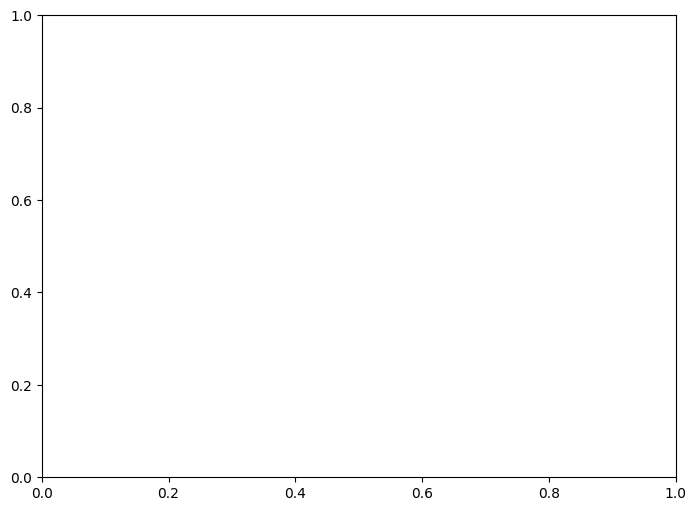

In [2]:
# plot fakeprint
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
for i, fp in enumerate(ai_fps_norm):
    plt.plot(freqs, fp, label=f"AI Fakeprint {i+1}")
plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("fakeprints")
plt.title("AI Fakeprint vs Frequency")

plt.subplot(1, 2, 2)
for i, fp in enumerate(human_fps_norm):
    plt.plot(freqs, fp, label=f"Human Fakeprint {i+1}")
plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("fakeprints")
plt.title("Human Fakeprint vs Frequency")

plt.grid()

In [ ]:
ai_mean_fp = ai_fps_norm.mean(axis=0)
human_mean_fp = human_fps_norm.mean(axis=0)
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.plot(freqs, ai_mean_fp, label="Mean AI Fakeprint")
plt.xscale("log")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(freqs, human_mean_fp, label="Mean Human Fakeprint")
plt.xscale("log")
plt.legend()
plt.show()

In [ ]:
# compute variances/covariances
ai_cov_matrix = np.cov(ai_fps_norm.T)  # (F, F)
ai_variances = np.diag(ai_cov_matrix)  # (F,)

human_cov_matrix = np.cov(human_fps_norm.T)  # (F, F)
human_variances = np.diag(human_cov_matrix)  # (F,)

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.plot(freqs, ai_variances, label="Variance of AI Fakeprints")
plt.plot(freqs, ai_mean_fp, label="Mean AI Fakeprint")
plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Variance")
plt.title("Variance of AI Fakeprints vs Frequency")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(freqs, human_variances, label="Variance of Human Fakeprints")
plt.plot(freqs, human_mean_fp, label="Mean Human Fakeprint")
plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Variance")
plt.title("Variance of Human Fakeprints vs Frequency")
plt.grid()
plt.legend()

plt.show()

In [ ]:
# plot covariances
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.imshow(ai_cov_matrix, aspect="auto", origin="lower", extent=[freqs.min(), freqs.max(), freqs.min(), freqs.max()])
plt.xscale("log")
plt.yscale("log")
plt.colorbar(label="Covariance")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Frequency (Hz)")
plt.title("Covariance Matrix of AI Fakeprints")

plt.subplot(1, 2, 2)
plt.imshow(human_cov_matrix, aspect="auto", origin="lower", extent=[freqs.min(), freqs.max(), freqs.min(), freqs.max()])
plt.xscale("log")
plt.yscale("log")
plt.colorbar(label="Covariance")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Frequency (Hz)")
plt.title("Covariance Matrix of Human Fakeprints")

plt.show()

In [ ]:
# plot fakeprint
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(freqs, weights, label="Fakeprint")
plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("weights")
plt.title("Weights vs Frequency")
plt.grid()

In [ ]:
ai_ccs = []
for ai_fp in ai_fps_norm:
    ai_cc = np.correlate(ai_fp, ai_mean_fp, mode='same')
    ai_ccs.append(ai_cc)
ai_ccs = np.array(ai_ccs)

human_ccs = []
for human_fp in human_fps_norm:
    human_cc = np.correlate(human_fp, human_mean_fp, mode='same')
    human_ccs.append(human_cc)
human_ccs = np.array(human_ccs)

lag = np.arange(-len(ai_mean_fp) + 1, len(ai_mean_fp))

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
for i, ai_cc in enumerate(ai_ccs):
    plt.plot(lag, ai_cc, label=f"AI Cross-Correlation {i+1}")
plt.xlabel("Lag")
plt.ylabel("Cross-Correlation")
plt.title("Cross-Correlation of AI Fakeprints with Mean AI Fakeprint")
plt.grid()

plt.subplot(1, 2, 2)
for i, human_cc in enumerate(human_ccs):
    plt.plot(lag, human_cc, label=f"Human Cross-Correlation {i+1}")
plt.xlabel("Lag")
plt.ylabel("Cross-Correlation")
plt.title("Cross-Correlation of Human Fakeprints with Mean Human Fakeprint")
plt.grid()

plt.show()

In [ ]:
with torch.inference_mode():
    ai_logits, ai_cross_corrs = model(torch.from_numpy(ai_fps_norm).to(next(model.parameters()).device), convolve=True)
    human_logits, human_cross_corrs = model(torch.from_numpy(human_fps_norm).to(next(model.parameters()).device), convolve=True)
    ai_cross_corrs = ai_cross_corrs.squeeze().detach().cpu().numpy()
    human_cross_corrs = human_cross_corrs.squeeze().detach().cpu().numpy()

lag = torch.arange(-len(ai_cross_corrs[1]) // 2 + 1, len(ai_cross_corrs[1]) // 2 + 1)

# plot cross-correlation
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
for i, cross_corr in enumerate(ai_cross_corrs):
    plt.plot(lag, cross_corr, label=f"Cross-correlation {i+1}")
plt.xlabel("Lag")
plt.ylabel("Cross-correlation")
plt.title("Cross-correlation of AI Fakeprint with Linear Weights")
plt.grid()

plt.subplot(1, 2, 2)
for i, cross_corr in enumerate(human_cross_corrs):
    plt.plot(lag, cross_corr, label=f"Cross-correlation {i+1}")
plt.xlabel("Lag")
plt.ylabel("Cross-correlation")
plt.title("Cross-correlation of Human Fakeprint with Linear Weights")
plt.grid()

plt.show()